# Simeer Examples

Simeer is an optimal replacement for the `simulate_sky_TOD` step of `limTOD` specialised for the MeerKLASS holographic primary beam. It avoids the HEALPix spherical-harmonic rotation path by working directly on the beam's native direction-cosine grid `(l, m)` for every pointing.

This notebook mirrors the structure of `limTOD/examples/TODsim_examples.ipynb` and shows:

1. A quick-start TOD simulation with a synthetic Gaussian beam (runs anywhere, no real beam file required).
2. Loading the **real MeerKLASS holographic beam** from NPZ and inspecting it across frequency.
3. A multi-frequency point-source sanity check using the real beam.
4. Joblib-parallelised TOD over a realistic frequency band using the real beam.
5. Side-by-side comparison with `limTOD`'s HEALPix-SH path on a synthetic Gaussian (requires `limTOD` installed).

Run all cells top to bottom. Sections 2-4 expect the real beam NPZ at the path set in section 2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from simeer import (
    MeerKLASSBeam,
    synthetic_gaussian_beam,
    integrate_tod,
    integrate_sample,
)
from simeer.projection import horizon_to_equatorial

MEERKAT_LAT = -30.7130  # degrees
MEERKAT_LON = 21.4430
MEERKAT_HEIGHT_M = 1054

## 1. Quick start: synthetic beam + uniform sky

The fastest sanity check. A uniform `T_sky = 10 K` sky should integrate back to ~10 K antenna temperature for every sample (the integrator normalises by the beam solid angle `Omega_b`).

tod.shape = (3, 64)
mean over all samples = 10.0015  (expected ~ 10.0)


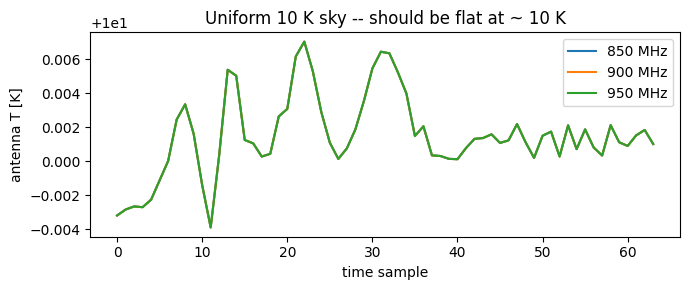

In [2]:
# Synthetic +/-6 deg beam at three demonstration frequencies, FWHM ~ 1.5 deg.
freq_MHz = np.array([850.0, 900.0, 950.0])
margin_deg = np.linspace(-6, 6, 121)
synth_beam = synthetic_gaussian_beam(
    freq_MHz=freq_MHz, margin_deg=margin_deg, fwhm_deg=1.5
)

nside = 128
T0 = 10.0
sky_cube = np.full((len(freq_MHz), hp.nside2npix(nside)), T0, dtype=np.float64)

ntime = 64
lst_deg = np.linspace(100.0, 110.0, ntime)
az_deg = np.linspace(170.0, 190.0, ntime)
el_deg = np.full(ntime, 45.0)

tod = integrate_tod(
    lst_deg_list=lst_deg,
    az_deg_list=az_deg,
    el_deg_list=el_deg,
    lat_deg=MEERKAT_LAT,
    beam=synth_beam,
    sky_maps=sky_cube,
    freq_MHz=freq_MHz,
    disc_radius_deg=8.0,
)

print(f'tod.shape = {tod.shape}')
print(f'mean over all samples = {tod.mean():.4f}  (expected ~ {T0:.1f})')

fig, ax = plt.subplots(figsize=(7, 3))
for i, f in enumerate(freq_MHz):
    ax.plot(tod[i], label=f'{f:.0f} MHz')
ax.set_xlabel('time sample')
ax.set_ylabel('antenna T [K]')
ax.legend()
ax.set_title('Uniform 10 K sky -- should be flat at ~ 10 K')
fig.tight_layout()

## 2. Loading the real MeerKLASS beam

The MeerKLASS U-band holographic beam ships as a ~35 GB NPZ archive with 65 antennas (`m000`..`m063` plus `array_average`), 4 Jones polarisations, 1024 frequency channels from 544 to 1087 MHz, on a 128x128 grid in direction-cosine space spanning +/-6 degrees.

`MeerKLASSBeam` loads only the antenna and polarisations you ask for. Default is `array_average` with `HH` + `VV`, which gives a working-set size of ~135 MB in `float32`.

In [3]:
from pathlib import Path
from time import perf_counter

BEAM_PATH = Path('/Users/zzhang/Dataspace/MeerKLASS/beam/MeerKAT_U_band_primary_beam.npz')

if not BEAM_PATH.exists():
    raise FileNotFoundError(
        f'Real MeerKLASS beam not found at {BEAM_PATH}. '
        'Sections 2-4 will not run; set BEAM_PATH to your local copy.'
    )

t0 = perf_counter()
beam = MeerKLASSBeam(BEAM_PATH, antenna='array_average', polarizations=('HH', 'VV'))
print(f'Loaded in {perf_counter() - t0:.1f} s')
print(beam)
print(f'freq grid: {beam.freq_MHz.size} channels from {beam.freq_MHz[0]:.1f} to {beam.freq_MHz[-1]:.1f} MHz')
print(f'(m, l) grid: {beam.margin_deg.size}**2 points from {beam.beam_extent_deg[0]:.2f} to {beam.beam_extent_deg[1]:.2f} deg')
print(f'HH cube memory: {beam.power_cube("HH").nbytes / 1e6:.1f} MB ({beam.power_cube("HH").dtype})')

Loaded in 11.3 s
MeerKLASSBeam(file='MeerKAT_U_band_primary_beam.npz', freq=544.0-1087.5 MHz, extent=[-6.00, 5.91] deg, pols=('HH', 'VV'))
freq grid: 1024 channels from 544.0 to 1087.5 MHz
(m, l) grid: 128**2 points from -6.00 to 5.91 deg
HH cube memory: 67.1 MB (float32)


Omega_b(HH) at 544 / 800 / 1087 MHz: 2.352 / 1.032 / 0.597 msr


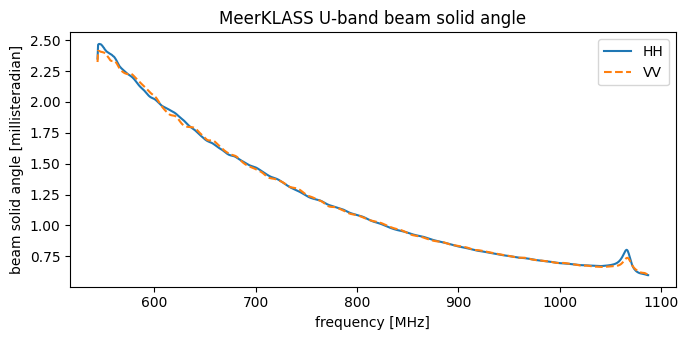

In [4]:
# Inspect Omega_b(freq): the beam contracts as frequency rises (Omega_b ~ 1/f^2 for a diffraction-limited dish).
omega_b_HH = beam.beam_solid_angle('HH')
omega_b_VV = beam.beam_solid_angle('VV')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(beam.freq_MHz, omega_b_HH * 1e3, label='HH')
ax.plot(beam.freq_MHz, omega_b_VV * 1e3, label='VV', linestyle='--')
ax.set_xlabel('frequency [MHz]')
ax.set_ylabel('beam solid angle [millisteradian]')
ax.set_title('MeerKLASS U-band beam solid angle')
ax.legend()
fig.tight_layout()

print(f'Omega_b(HH) at 544 / 800 / 1087 MHz: '
      f'{omega_b_HH[0]*1e3:.3f} / {omega_b_HH[len(beam.freq_MHz)//2]*1e3:.3f} / '
      f'{omega_b_HH[-1]*1e3:.3f} msr')

Text(0.5, 1.02, 'MeerKLASS HH primary beam (array average)')

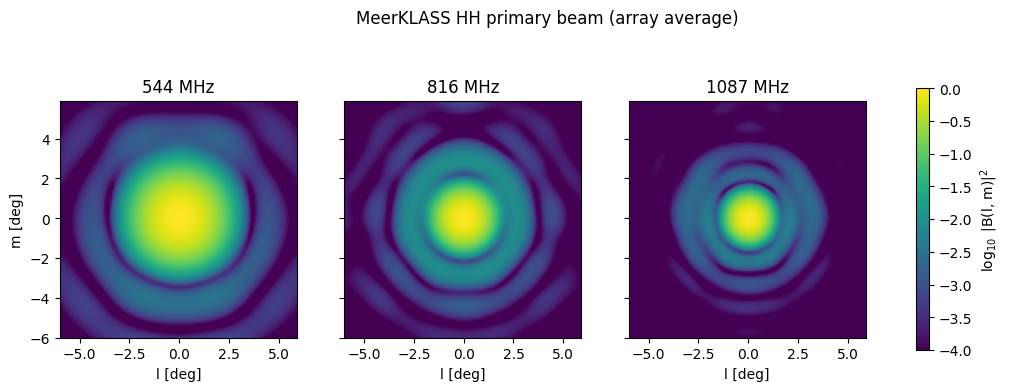

In [5]:
# Visualise the HH power beam at three frequencies (low / mid / high band) to show the frequency squeeze.
cube = beam.power_cube('HH')
extent = [beam.beam_extent_deg[0], beam.beam_extent_deg[1]] * 2
freq_indices = [0, len(beam.freq_MHz) // 2, len(beam.freq_MHz) - 1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, idx in zip(axes, freq_indices):
    im = ax.imshow(
        np.log10(cube[idx] + 1e-12),
        extent=extent,
        origin='lower',
        aspect='equal',
        vmin=-4,
        vmax=0,
        cmap='viridis',
    )
    ax.set_xlabel('l [deg]')
    ax.set_title(f'{beam.freq_MHz[idx]:.0f} MHz')
axes[0].set_ylabel('m [deg]')
fig.colorbar(im, ax=axes, label=r'$\log_{10}$ |B(l, m)|$^2$', shrink=0.85)
fig.suptitle('MeerKLASS HH primary beam (array average)', y=1.02)

## 3. Point source at the pointing direction (real beam)

Place a single bright pixel where the antenna is pointing and confirm the integrator returns `T_src * dOmega_pix / Omega_b * B(offset)` for several real beam channels. The residual versus the naive `T_src * dOmega_pix / Omega_b` is the small B(offset) factor caused by the pixel-to-pointing offset.

In [6]:
nside = 256
sky_npix = hp.nside2npix(nside)

az_p, el_p, lst, lat = 180.0, 60.0, 180.0, MEERKAT_LAT
ra_p, dec_p = horizon_to_equatorial(az_p, el_p, lst, lat)
theta = np.deg2rad(90.0 - float(dec_p))
phi = np.deg2rad(float(ra_p) % 360.0)
src_pix = hp.ang2pix(nside, theta, phi)

# Five evenly-spaced channels across U-band.
channel_picks = np.linspace(0, len(beam.freq_MHz) - 1, 5).astype(int)
freq_subset = beam.freq_MHz[channel_picks]

sky_cube = np.zeros((len(freq_subset), sky_npix), dtype=np.float64)
sky_cube[:, src_pix] = 1.0e3  # 1000 K point source at every channel

sample = integrate_sample(
    lst_deg=lst, az_pointing_deg=az_p, el_pointing_deg=el_p, lat_deg=lat,
    beam=beam, sky_maps=sky_cube,
    beam_freq_indices=channel_picks,
    disc_radius_deg=8.0,
)

d_omega_pix = 4 * np.pi / sky_npix
omega_b_picks = beam.beam_solid_angle('HH')[channel_picks]
naive_expected = 1.0e3 * d_omega_pix / omega_b_picks

print(f'{ "freq [MHz]":>12} {"integrated [K]":>16} {"naive T0*dOmega/Omega_b [K]":>30}')
for f, s, n in zip(freq_subset, sample, naive_expected):
    print(f'{f:>12.1f} {s:>16.3f} {n:>30.3f}')

  freq [MHz]   integrated [K]    naive T0*dOmega/Omega_b [K]
       544.0            6.726                          6.795
       679.5           10.066                         10.254
       815.5           15.039                         15.463
       951.5           20.650                         21.286
      1087.5           25.474                         26.761


## 4. Joblib-parallel scan (real beam)

A representative scan over an azimuth raster, using a sub-band of the real beam. `integrate_tod(..., n_jobs=-1)` uses every available core via joblib's Loky process backend; `n_jobs=1` runs serially. See `scripts/benchmark.py` for the full scaling study (~10x on 28 cores at production size).

        serial: 0.131 s for 256 samples x 16 freq


 parallel (-1): 2.289 s for 256 samples x 16 freq


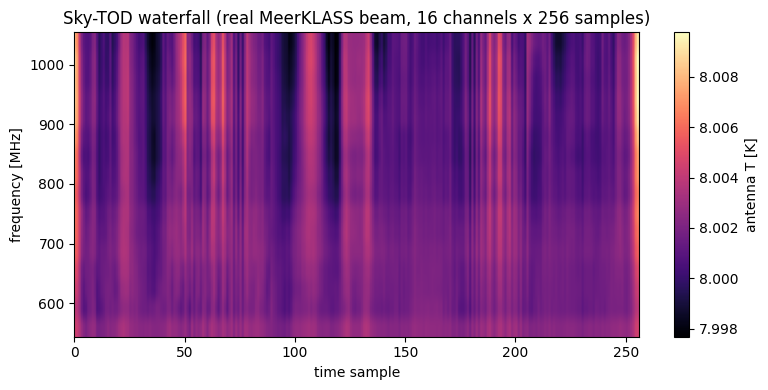

In [7]:
# Subsample every 64th channel of the real beam (16 channels spanning U-band).
step = 64
channel_picks = np.arange(0, len(beam.freq_MHz), step)
freq_subset = beam.freq_MHz[channel_picks]

ntime = 256
lst_deg = np.linspace(0.0, 30.0, ntime)
az_deg = np.full(ntime, 180.0) + 3.0 * np.sin(np.linspace(0, 4 * np.pi, ntime))
el_deg = np.full(ntime, 41.5)

nside_sky = 128
sky_cube = np.full((len(freq_subset), hp.nside2npix(nside_sky)), 8.0, dtype=np.float64)

for n_jobs in (1, -1):
    t0 = perf_counter()
    tod = integrate_tod(
        lst_deg_list=lst_deg, az_deg_list=az_deg, el_deg_list=el_deg,
        lat_deg=MEERKAT_LAT, beam=beam, sky_maps=sky_cube,
        freq_MHz=freq_subset, disc_radius_deg=8.0, n_jobs=n_jobs,
    )
    elapsed = perf_counter() - t0
    label = 'serial' if n_jobs == 1 else 'parallel (-1)'
    print(f'{label:>14}: {elapsed:.3f} s for {ntime} samples x {len(freq_subset)} freq')

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(
    tod,
    aspect='auto',
    origin='lower',
    extent=[0, ntime, freq_subset[0], freq_subset[-1]],
    cmap='magma',
)
ax.set_xlabel('time sample')
ax.set_ylabel('frequency [MHz]')
ax.set_title(f'Sky-TOD waterfall (real MeerKLASS beam, {len(freq_subset)} channels x {ntime} samples)')
fig.colorbar(im, ax=ax, label='antenna T [K]')
fig.tight_layout()

## 5. Side-by-side with `limTOD` (synthetic beam, optional)

When `limTOD` is installed, we cross-check the Simeer disc path against limTOD's HEALPix-SH path using a symmetric Gaussian beam. We deliberately keep this comparison on a synthetic beam: limTOD requires the beam in HEALPix form, and converting the real (l, m) cube to HEALPix at high enough nside to preserve the +/-6 degree support would add a discretisation that obscures the integrator agreement we actually want to validate.

In [8]:
try:
    from limTOD import TODSim, example_scan, example_symm_beam_map  # noqa: F401
    from limTOD.sky_model import GDSM_sky_model  # noqa: F401

    HAS_LIMTOD = True
except ImportError:
    print('limTOD not installed -- skipping side-by-side comparison.')
    HAS_LIMTOD = False

limTOD not installed -- skipping side-by-side comparison.


In [9]:
if HAS_LIMTOD:
    from simeer import SimeerTODSim

    # Match the same Gaussian beam on both sides for a fair comparison.
    sim_simeer = SimeerTODSim(
        beam=synthetic_gaussian_beam(
            freq_MHz=np.array([1000.0]),
            margin_deg=np.linspace(-6, 6, 121),
            fwhm_deg=2.5,
        ),
        sky_func=GDSM_sky_model,
        sky_nside=128,
        disc_radius_deg=8.0,
    )
    sim_limtod = TODSim(
        beam_func=lambda *, freq, nside: example_symm_beam_map(freq=freq, nside=nside, FWHM=2.5),
        sky_func=GDSM_sky_model,
        sky_nside=128,
        beam_nside=256,
    )

    time_list, az_list = example_scan(dt=2.0)
    tod_simeer = sim_simeer.simulate_sky_TOD(
        freq_list=[1000.0], time_list=time_list[:50],
        azimuth_deg_list=az_list[:50], elevation_deg=41.5,
    )
    tod_limtod = sim_limtod.simulate_sky_TOD(
        freq_list=[1000.0], time_list=time_list[:50],
        azimuth_deg_list=az_list[:50], elevation_deg=41.5,
    )

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(tod_simeer[0], label='Simeer (disc + (l, m) bilinear)')
    ax.plot(tod_limtod[0], '--', label='limTOD (HEALPix SH rotation)')
    ax.set_xlabel('time sample')
    ax.set_ylabel('antenna T [K]')
    ax.legend()
    fig.tight_layout()

    rel = np.abs(tod_simeer[0] - tod_limtod[0]) / np.abs(tod_limtod[0])
    print(f'median relative agreement: {np.median(rel):.4f}')

## Next steps

- See `examples/quickstart.py` for the minimal-no-notebook version.
- See `scripts/benchmark.py` for the full performance characterisation (10x scaling at 28 cores on a realistic problem).